# Q5: Pattern Analysis

**Phase 6:** Pattern Analysis & Advanced Visualization  
**Points: 6 points**

**Focus:** Identify trends over time, analyze seasonal patterns, create correlation analysis.

**Lecture Reference:** Lecture 11, Notebook 3 ([`11/demo/03_pattern_analysis_modeling_prep.ipynb`](https://github.com/christopherseaman/datasci_217/blob/main/11/demo/03_pattern_analysis_modeling_prep.ipynb)), Phase 6. Also see Lecture 08 (groupby) and Lecture 07 (visualization).

---

## Setup

In [1]:
# Import libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import seaborn as sns
import os

# Load feature-engineered data from Q4
#df = pd.read_csv('output/q4_features.csv', parse_dates=['Measurement Timestamp'], index_col='Measurement Timestamp')
# Or if you saved without index:
df = pd.read_csv('output/q4_features.csv')
df['Measurement Timestamp'] = pd.to_datetime(df['Measurement Timestamp'])
df = df.set_index('Measurement Timestamp')
print(f"Loaded {len(df):,} records with features")

Loaded 121,076 records with features


In [2]:
# revert precipitation column back to numeric; changes from 0-3
# 0 no change, 1 unspecified, 2 liquid precipitation, 3 solid precipitation
"""
precipitation_map_revert = {
    'no_precipitation':0,
    'unspecified':1,
    'liquid_precipitation':2,
    'solid_precipitation':3
}
df['Precipitation Type'] = df['Precipitation Type'].map(precipitation_map_revert)
"""

"\nprecipitation_map_revert = {\n    'no_precipitation':0,\n    'unspecified':1,\n    'liquid_precipitation':2,\n    'solid_precipitation':3\n}\ndf['Precipitation Type'] = df['Precipitation Type'].map(precipitation_map_revert)\n"

In [3]:
# create a correlation matrix of key variables

var_range = [df.columns[1:14],
            df.columns[17:29]
]
key_vars = []

for i in var_range:
    for col in i:
            key_vars.append(col)
print(key_vars)

df_corr = df[key_vars].corr()
df_corr.to_csv('output/q5_correlations.csv')
print('\nCalculated correlation coefficients and saved to output/q5_correlations.csv')

['Air Temperature', 'Wet Bulb Temperature', 'Humidity', 'Rain Intensity', 'Interval Rain', 'Total Rain', 'Precipitation Type', 'Wind Direction', 'Wind Speed', 'Maximum Wind Speed', 'Barometric Pressure', 'Solar Radiation', 'Heading', 'dew_point', 'Rain Intensity_log', 'Interval Rain_log', 'Total Rain_log', 'Wind Direction_log', 'Maximum Wind Speed_log', 'Solar Radiation_log', 'gust_factor', 'barometric_pressure_rolling_7h', 'barometric_pressure_rolling_12h', 'humidity_rolling_12h', 'humidity_rolling_24h']

Calculated correlation coefficients and saved to output/q5_correlations.csv


/var/folders/6h/ch1ltdnj3v33nkw2k13k_h8w0000gn/T/ipykernel_16938/3389599580.py:37: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  monthly_avg_temperature = df['Air Temperature'].resample('M').mean().groupby(lambda x: x.month).mean()
/var/folders/6h/ch1ltdnj3v33nkw2k13k_h8w0000gn/T/ipykernel_16938/3389599580.py:56: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  monthly_avg_humidity = df['Humidity'].resample('M').mean().groupby(lambda x: x.month).mean()
/var/folders/6h/ch1ltdnj3v33nkw2k13k_h8w0000gn/T/ipykernel_16938/3389599580.py:73: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  monthly_avg_dp = df['dew_point'].resample('M').mean().groupby(lambda x: x.month).mean()
/var/folders/6h/ch1ltdnj3v33nkw2k13k_h8w0000gn/T/ipykernel_16938/3389599580.py:80: UserWarning: This figure was using a layout engine that is incompatible with subp

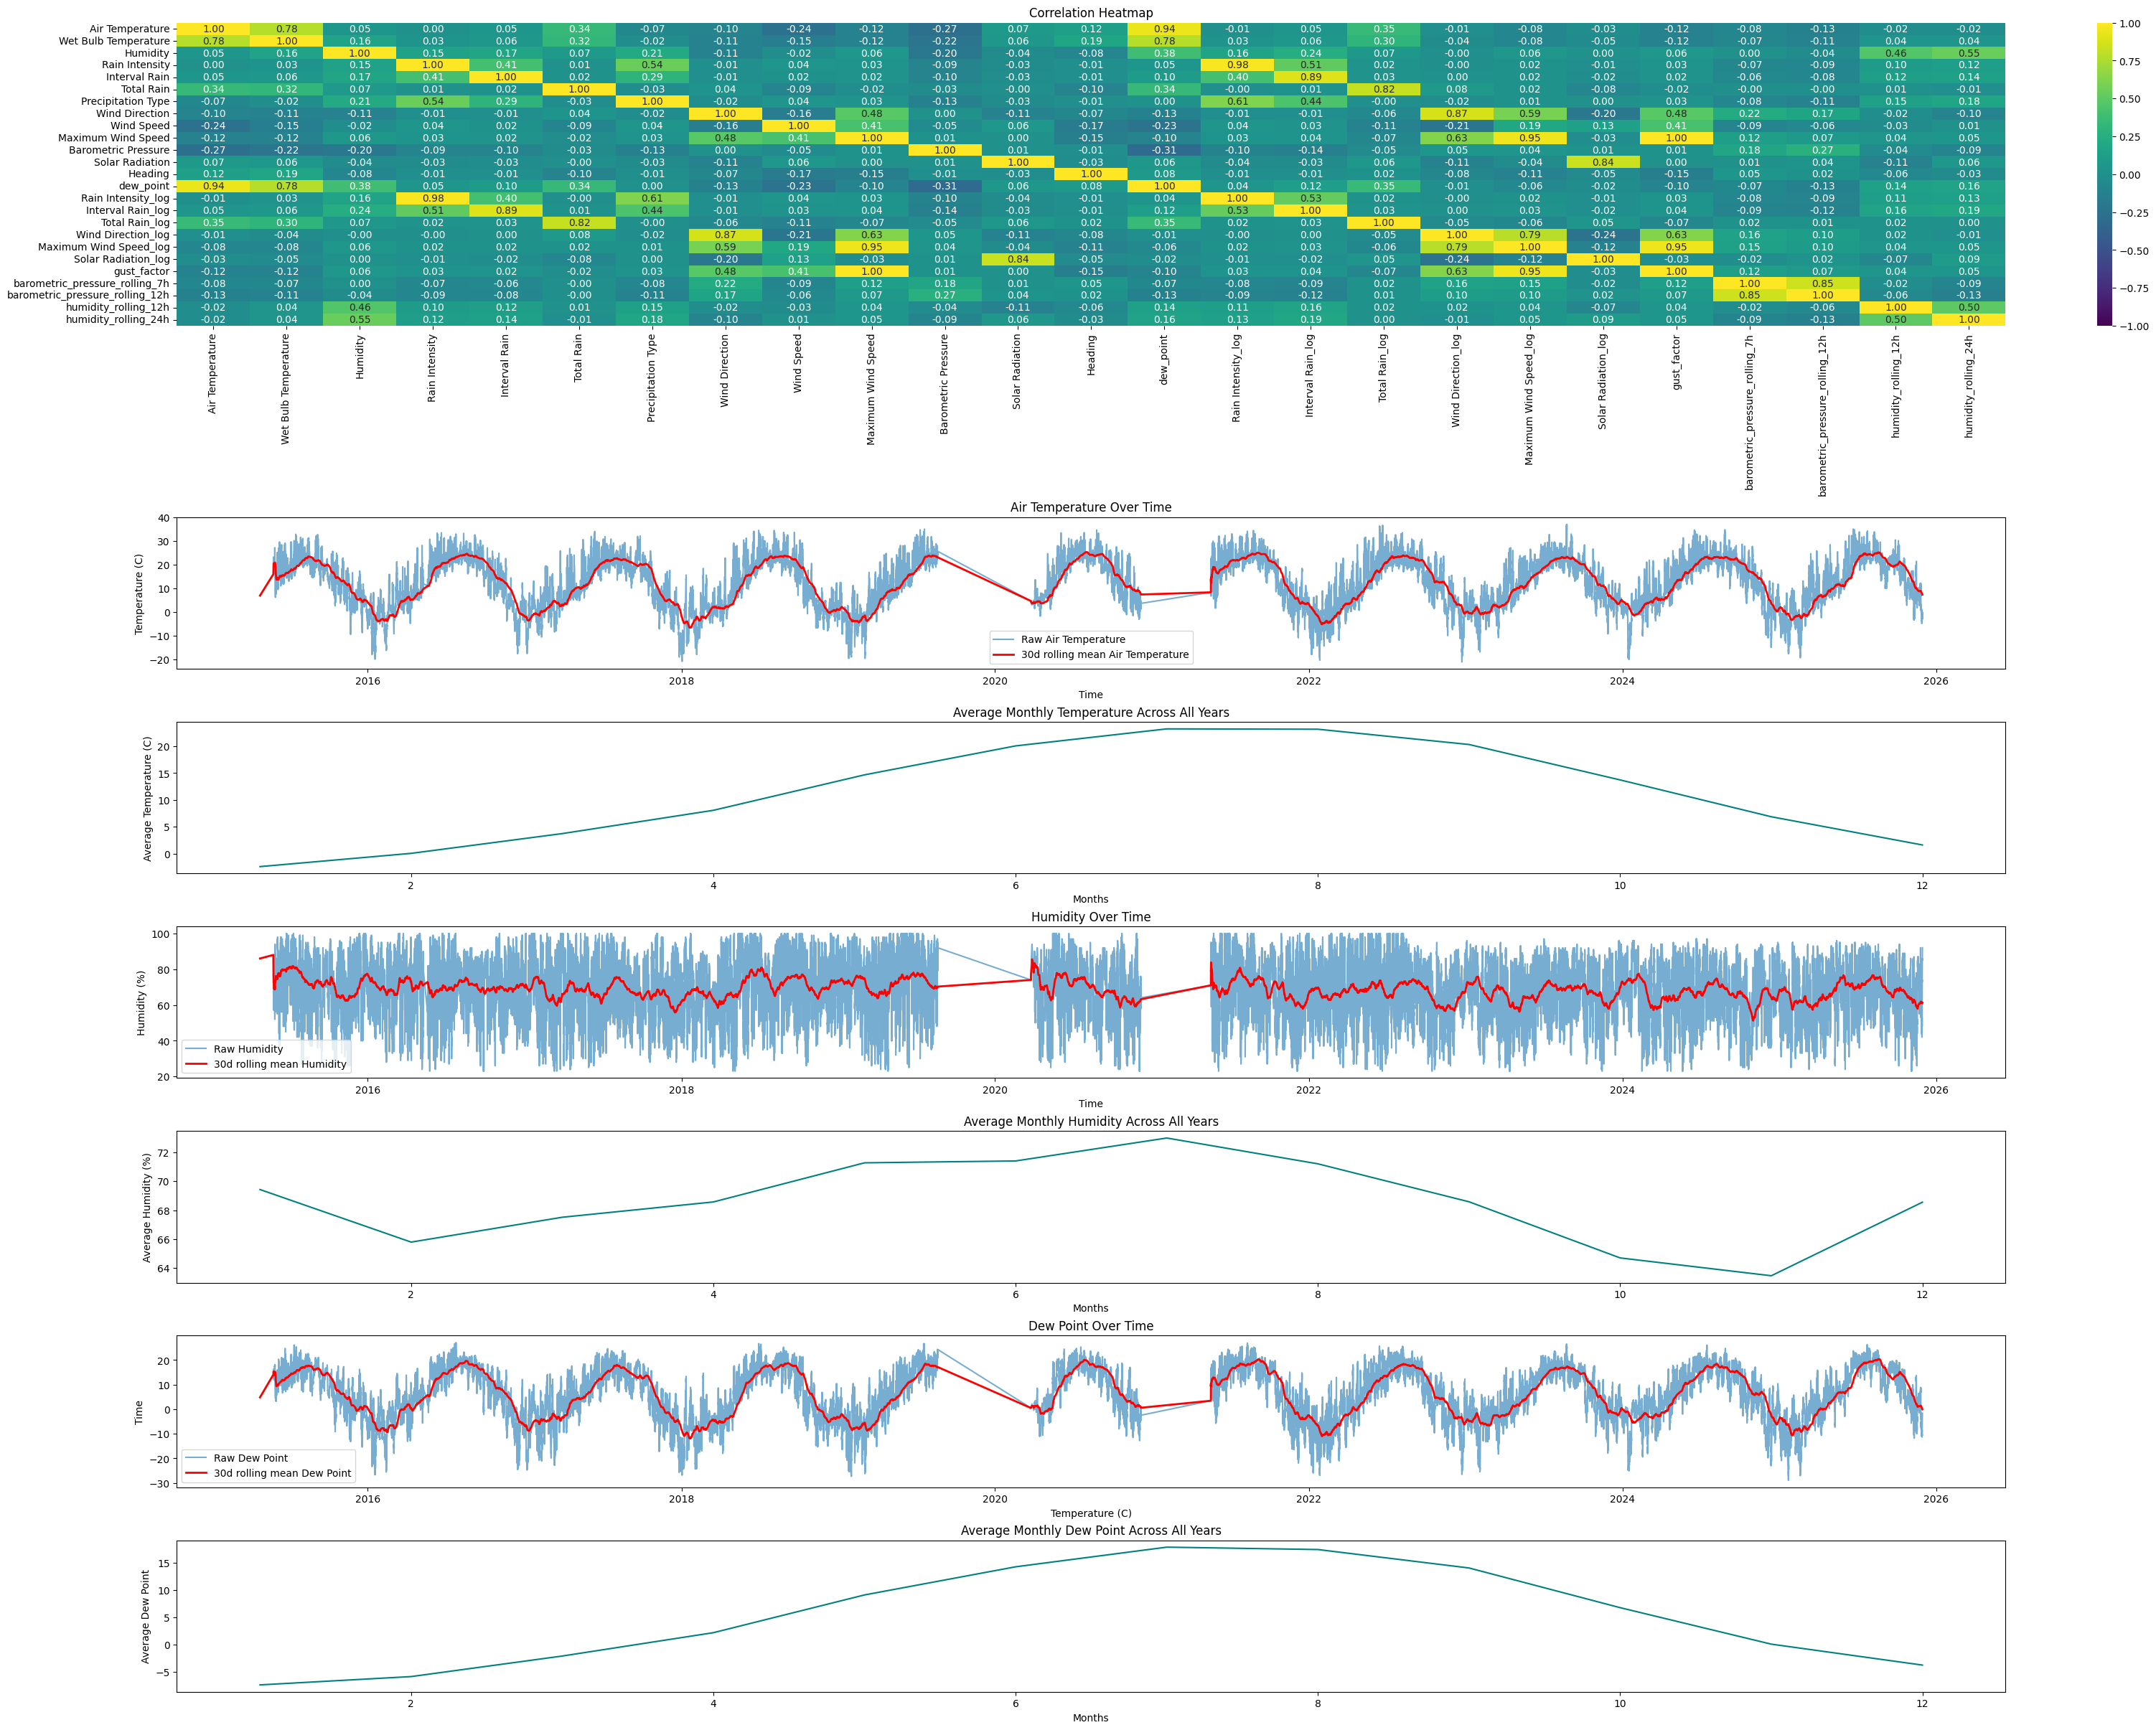

In [4]:
# visualizations

fig, axes = plt.subplots(
    7, 1,
    figsize=(30, 24),
    gridspec_kw={'height_ratios': [2, 1, 1, 1, 1, 1, 1]},
    constrained_layout=True
)

## correlation heatmap

sns.heatmap(
    df_corr,
    vmin=-1,
    vmax=1,
    cmap='viridis',
    annot=True,
    fmt='.2f',
    ax=axes[0])

axes[0].set_title('Correlation Heatmap')


## looking at the raw data and rolling 30 day means

temp_over_time = df['Air Temperature']
rolling_30d = df['Air Temperature'].rolling('30d').mean()

axes[1].plot(df.index, temp_over_time, alpha=0.6, label='Raw Air Temperature')
axes[1].plot(df.index, rolling_30d, color='red', linewidth=2, label='30d rolling mean Air Temperature')
axes[1].legend()
axes[1].set_title('Air Temperature Over Time')
axes[1].set_xlabel('Time')
axes[1].set_ylabel('Temperature (C)')

## get average monthly temperature over all 10+ years
monthly_avg_temperature = df['Air Temperature'].resample('M').mean().groupby(lambda x: x.month).mean()

axes[2].plot(monthly_avg_temperature.index, monthly_avg_temperature.values, color='teal')
axes[2].set_xlabel('Months')
axes[2].set_ylabel('Average Temperature (C)')
axes[2].set_title('Average Monthly Temperature Across All Years')


humidity_over_time = df['Humidity']
humidity_rolling_30d = df['Humidity'].rolling('30d').mean()

axes[3].plot(df.index, humidity_over_time, alpha=0.6, label='Raw Humidity')
axes[3].plot(df.index, humidity_rolling_30d, color='red', linewidth=2, label='30d rolling mean Humidity')
axes[3].legend()
axes[3].set_title('Humidity Over Time')
axes[3].set_xlabel('Time')
axes[3].set_ylabel('Humidity (%)')

## look at humidity over all months over the 10+ year period
monthly_avg_humidity = df['Humidity'].resample('M').mean().groupby(lambda x: x.month).mean()

axes[4].plot(monthly_avg_humidity.index, monthly_avg_humidity.values, color='teal')
axes[4].set_xlabel('Months')
axes[4].set_ylabel('Average Humidity (%)')
axes[4].set_title('Average Monthly Humidity Across All Years')

## look at dew point 
dp = df['dew_point']
dp_rolling_30d = df['dew_point'].rolling('30d').mean()
axes[5].plot(df.index, dp, alpha=0.6,label='Raw Dew Point')
axes[5].plot(df.index, dp_rolling_30d, color = 'red', linewidth=2, label='30d rolling mean Dew Point')
axes[5].legend()
axes[5].set_title('Dew Point Over Time')
axes[5].set_xlabel('Temperature (C)')
axes[5].set_ylabel('Time')

monthly_avg_dp = df['dew_point'].resample('M').mean().groupby(lambda x: x.month).mean()

axes[6].plot(monthly_avg_dp.index, monthly_avg_dp.values, color='teal')
axes[6].set_xlabel('Months')
axes[6].set_ylabel('Average Dew Point')
axes[6].set_title('Average Monthly Dew Point Across All Years')

plt.subplots_adjust(hspace=0.5)
plt.savefig('output/q5_patterns.png', dpi=200)


In [5]:
"""
### 3. `output/q5_trend_summary.txt`
**Format:** Plain text file
**Content:** Brief text summary of key patterns identified
**Required information:**
- Temporal trends (increasing, decreasing, stable)
- Seasonal patterns (daily, weekly, monthly cycles)
- Key correlations (mention 2-3 strongest correlations)
"""

# key patterns identified

with open('output/q5_trend_summary.txt', 'w') as f:
    f.write('===KEY PATTERNS IDENTIFIED===\n\n')
    f.write('Temporal Trends:\n')
    f.write('- Air Temperature is higher on average in the summer months, lower in the winter months\n')
    f.write('- Humidity is higher on average in the summer months, lower in the winter months\n')
    f.write('- Dew Point is higher on average in the summer and fall months, and lower in the winter and early spring months\n\n')
    f.write('Correlations:\n')
    f.write('- Dew Point has a very high positive correlation with Wet Bulb Temperature: r = 0.79\n')
    f.write('- Wet Bulb Temperature has a high positive correlation with Air Temperature: r = 0.79\n')
    f.write('- Gust Factor has a moderate positive correlation with Wind Direction: r = 0.42\n')
    f.write('- Precipitation type has a moderate positive correlation with Rain Intensity: r = 0.55')
            


---

## Objective

Identify trends over time, analyze seasonal patterns, and create correlation analysis.

**Time Series Note:** Time series data has temporal patterns (trends, seasonality, cycles). Use time-based aggregations and visualizations to identify these patterns. See **Lecture 09** for time series decomposition and pattern analysis. Use pandas `resample()` to aggregate by time periods (e.g., `resample('ME')` for monthly, `resample('D')` for daily) and `groupby()` with temporal features (hour, day_of_week, month) to identify patterns.

---

## Required Artifacts

You must create exactly these 3 files in the `output/` directory:

### 1. `output/q5_correlations.csv`
**Format:** CSV file
**Content:** Correlation matrix (can be subset of key variables)
**Requirements:**
- Square matrix with variable names as both index and columns
- Values are correlation coefficients (between -1 and 1)
- Can be subset of key variables (e.g., top 10 most important variables)
- **Include index/column names** when saving: `corr_matrix.to_csv('output/q5_correlations.csv')`

**Example format:**
```csv
,Air Temperature,Water Temperature,Wind Speed,Humidity
Air Temperature,1.0,0.847,-0.234,-0.156
Water Temperature,0.847,1.0,0.123,0.089
Wind Speed,-0.234,0.123,1.0,0.456
Humidity,-0.156,0.089,0.456,1.0
```

### 2. `output/q5_patterns.png`
**Format:** PNG image file
**Content:** Advanced visualizations showing trends/seasonality
**Required visualizations (at least 2 of these):**
1. **Trend over time:** Line plot showing variable(s) over time (e.g., monthly averages)
2. **Seasonal pattern:** Bar plot or line plot showing patterns by month, day of week, or hour
3. **Correlation heatmap:** Heatmap of correlation matrix
4. **Multi-panel plot:** Multiple subplots showing different patterns

**Requirements:**
- Clear axis labels (xlabel, ylabel)
- Title for each subplot
- Overall figure title (optional but recommended)
- Legend if multiple series shown
- Saved as PNG with sufficient resolution (dpi=150 or higher)

### 3. `output/q5_trend_summary.txt`
**Format:** Plain text file
**Content:** Brief text summary of key patterns identified
**Required information:**
- Temporal trends (increasing, decreasing, stable)
- Seasonal patterns (daily, weekly, monthly cycles)
- Key correlations (mention 2-3 strongest correlations)

**Example format:**
```
KEY PATTERNS IDENTIFIED
======================

TEMPORAL TRENDS:
- Air and water temperatures show clear seasonal patterns
- Higher temperatures in summer months (June-August)
- Lower temperatures in winter months (December-February)
- Monthly air temp range: 4.2°C to 25.8°C

DAILY PATTERNS:
- Temperature shows diurnal cycle (warmer during day, cooler at night)
- Peak air temp typically at hour 14-15 (2-3 PM)
- Minimum air temp typically at hour 5-6 (5-6 AM)

CORRELATIONS:
- Air Temp vs Water Temp: 0.847 (strong positive correlation)
- Air Temp vs Humidity: -0.234 (moderate negative correlation)
- Wind Speed vs Wave Height: 0.612 (moderate positive correlation)
```

---

## Requirements Checklist

- [ ] Trends over time identified (increasing, decreasing, stable)
- [ ] Seasonal patterns analyzed (daily, weekly, monthly cycles)
- [ ] Correlation analysis completed
- [ ] Advanced visualizations created (multi-panel plots, grouped visualizations)
- [ ] Key patterns documented
- [ ] All 3 required artifacts saved with exact filenames

---

## Your Approach

1. **Identify trends** - Use `.resample()` to aggregate by time period and visualize long-term patterns
2. **Analyze seasonal patterns** - Use `.groupby()` with temporal features (hour, day_of_week, month)
3. **Create correlation analysis** - Compute correlation matrix for numeric columns
4. **Create visualizations** - Multi-panel plot showing trends, seasonal patterns, and correlations
5. **Document patterns** - Summarize key findings in text file

---

## Decision Points

- **Trend identification:** Is there a long-term trend? Is it increasing, decreasing, or stable? Use time series plots to visualize.
- **Seasonal patterns:** Are there daily patterns? Weekly? Monthly? Use aggregations and visualizations to identify.
- **Correlation analysis:** Which variables are correlated? Use correlation matrix and heatmaps. Focus on relationships that might be useful for modeling.

---

## Checkpoint

After Q5, you should have:
- [ ] Trends identified
- [ ] Seasonal patterns analyzed
- [ ] Correlations calculated
- [ ] Pattern visualizations created
- [ ] All 3 artifacts saved: `q5_correlations.csv`, `q5_patterns.png`, `q5_trend_summary.txt`

---

**Next:** Continue to `q6_modeling_preparation.md` for Modeling Preparation.
